In [1]:
import pandas as pd
import numpy as np
import nfl_data_py as nfl
from pygam import LinearGAM, s, f, te
import matplotlib.pyplot as plt
import data_processing_functions as helpy
import manual_ml_stuff as ml
import lightgbm as lgb
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [2]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

In [3]:
recieving_2024 = helpy.get_year_table(2024)
recieving_2023 = helpy.get_year_table(2023)
recieving_2022 = helpy.get_year_table(2022)
recieving_2021 = helpy.get_year_table(2021)
recieving_2020 = helpy.get_year_table(2020)
recieving_2019 = helpy.get_year_table(2019)
recieving_2018 = helpy.get_year_table(2018)

In [4]:
recieving = helpy.merge_datasets([recieving_2018, recieving_2019, recieving_2020, 
                                  recieving_2021, recieving_2022, recieving_2023, recieving_2024])

skills in order: efficency vs man and zone seperately, threat to all parts of the field, drops, positional value, translatability 

In [5]:
X = recieving[['behind_los_yards', 'short_yards', 'medium_yards', 'deep_yards', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate']]
    
y = recieving['pick']

In [6]:
X = X.fillna(0)

In [7]:
X['is_power_four'] = X['is_power_four'].astype(np.float32)

In [8]:
X_norm = (X - X.min()) / (X.max() - X.min())

In [9]:
# Convert to PyTorch tensors
X_tensor = torch.tensor(X_norm.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1)

In [10]:
# Dataset & DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [11]:
model = ml.NonMonotoneMultiplicativeModel()
loss_fn = nn.MSELoss()  # regression
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [12]:
def train_one_epoch(dataloader, model, loss_fn, optimizer):
    epoch_loss = 0
    for x_batch, y_batch in dataloader:
        optimizer.zero_grad()              # Step 1: reset gradients
        y_pred = model(x_batch)            # Step 2: forward pass
        loss = loss_fn(y_pred, y_batch)   # Step 3: compute loss
        loss.backward()                    # Step 4: backward pass (compute gradients)
        optimizer.step()                   # Step 5: update weights
        epoch_loss += loss.item() * x_batch.size(0)
    
    epoch_loss /= len(dataloader.dataset)
    return epoch_loss

In [13]:
n_epochs = 500
epoch_losses = []

for epoch in range(n_epochs):
    epoch_loss = train_one_epoch(dataloader, model, loss_fn, optimizer)
    epoch_losses.append(epoch_loss)

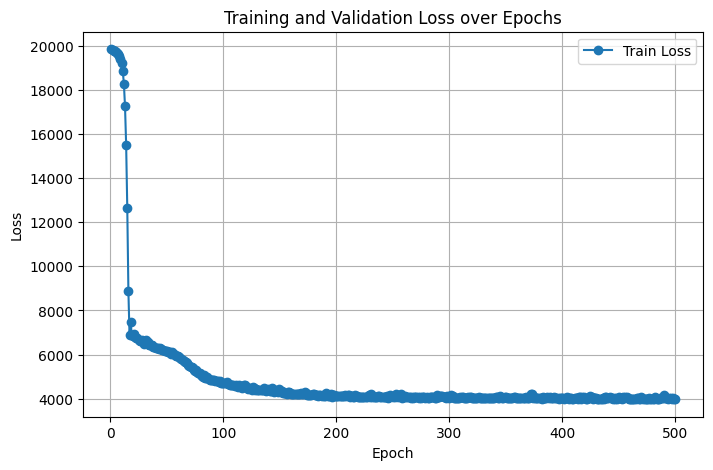

In [14]:
plt.figure(figsize=(8,5))
plt.plot(range(1, n_epochs+1), epoch_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
model.eval()
with torch.no_grad():  # no gradients needed for prediction
    y_pred = model(X_tensor)  # X: tensor of shape (num_samples, 11)

In [16]:
y_pred

tensor([[ 45.2596],
        [160.7460],
        [ 81.8239],
        [105.9443],
        [ 94.5343],
        [ 78.4015],
        [ 66.6209],
        [ 65.7672],
        [149.4291],
        [160.6669],
        [155.5079],
        [ 82.6296],
        [ 33.3171],
        [112.7008],
        [106.1572],
        [155.8193],
        [144.7717],
        [187.7517],
        [112.4323],
        [164.3933],
        [167.1431],
        [115.8694],
        [117.5774],
        [161.9136],
        [107.1687],
        [ 79.6001],
        [ 57.6529],
        [ 75.2031],
        [112.9944],
        [118.4444],
        [136.8977],
        [ 64.5462],
        [ 90.9942],
        [ 84.1442],
        [100.9745],
        [ 48.4325],
        [129.7248],
        [107.6839],
        [100.7082],
        [228.4743],
        [135.3804],
        [122.8888],
        [ 42.5779],
        [181.3878],
        [ 72.9802],
        [247.6746],
        [137.0999],
        [140.5175],
        [159.2839],
        [162.8344],


In [17]:
recieving['predicted_slot'] = y_pred

In [18]:
recieving[['behind_los_yards', 'short_yards', 'medium_yards', 'deep_yards', 'yprr',
               'is_power_four', 'drop_rate', 'wide_rate', 'player', 'college', 'is_power_four', 'predicted_slot']]

,behind_los_yards,short_yards,medium_yards,deep_yards,yprr,is_power_four,drop_rate,wide_rate,player,college,is_power_four,predicted_slot
0,170,351,470,705,4.15,False,5.6,55.8,Andy Isabella,Massachusetts,False,45.259556
1,21,513,386,423,2.33,False,12.7,3.0,John Ursua,Hawaii,False,160.746002
2,90,321,264,509,2.90,True,9.6,76.5,Dillon Mitchell,Oregon,True,81.823914
3,101,389,314,541,3.06,False,6.8,69.6,KeeSean Johnson,Fresno St.,False,105.944267
4,31,302,387,466,2.83,True,4.7,96.4,Kelvin Harmon,North Carolina St.,True,94.534309
5,104,457,359,387,3.01,True,5.6,40.4,A.J. Brown,Mississippi,True,78.401520
6,213,213,386,276,2.71,True,6.4,66.5,N'Keal Harry,Arizona St.,True,66.620903
7,441,408,169,53,3.47,True,5.2,11.5,Parris Campbell,Ohio St.,True,65.767159
8,0,368,390,379,3.06,False,6.7,16.3,Scott Miller,Bowling Green,False,149.429108
9,0,152,359,572,2.20,False,7.4,88.8,Travis Fulgham,Old Dominion,False,160.666946


In [19]:
print(y_tensor)

tensor([[ 62.],
        [236.],
        [239.],
        [174.],
        [206.],
        [ 51.],
        [ 32.],
        [ 59.],
        [208.],
        [184.],
        [ 67.],
        [103.],
        [ 25.],
        [ 93.],
        [ 36.],
        [ 66.],
        [203.],
        [247.],
        [171.],
        [149.],
        [126.],
        [ 56.],
        [ 76.],
        [187.],
        [ 64.],
        [ 22.],
        [ 92.],
        [161.],
        [207.],
        [ 59.],
        [151.],
        [ 15.],
        [ 49.],
        [ 81.],
        [200.],
        [ 25.],
        [217.],
        [ 46.],
        [166.],
        [212.],
        [168.],
        [ 21.],
        [ 17.],
        [173.],
        [ 33.],
        [176.],
        [220.],
        [ 57.],
        [187.],
        [165.],
        [214.],
        [252.],
        [ 10.],
        [129.],
        [ 34.],
        [219.],
        [ 85.],
        [131.],
        [ 91.],
        [ 20.],
        [204.],
        [ 82.],
        